<a href="https://colab.research.google.com/github/192512041simats-hari/IOE-AND-AI-SYSTEM/blob/main/IOE%20EXP_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


FINAL REPORT

     Vehicle  Engine Temperature   RPM  Fuel Level  Status
0  Vehicle 1                78.5  1800          65  NORMAL
1  Vehicle 2                92.0  3000          55  NORMAL
2  Vehicle 3               108.5  5200          30   ALERT
3  Vehicle 4                88.0  2600          70  NORMAL
4  Vehicle 5               112.0  5600          12   ALERT

Normal Vehicles : 3
Alert Vehicles  : 2

CSV File Saved Successfully


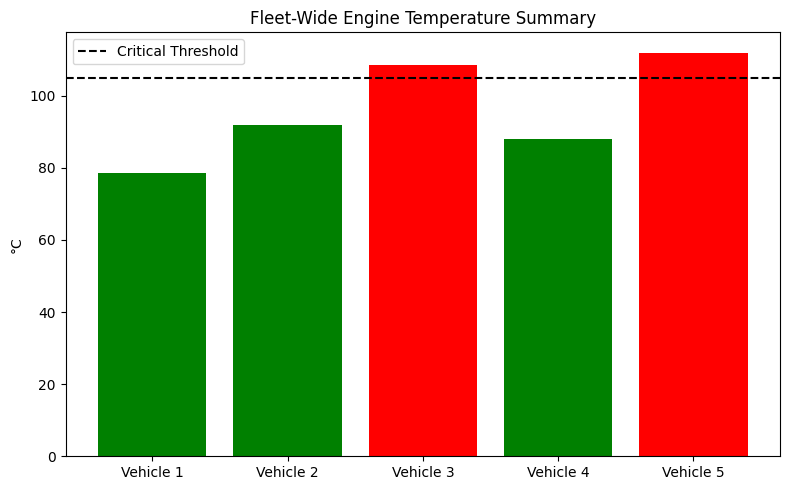

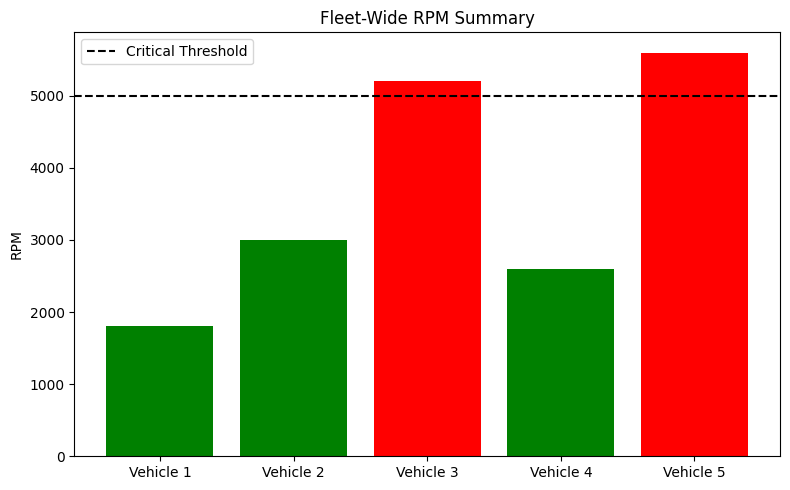

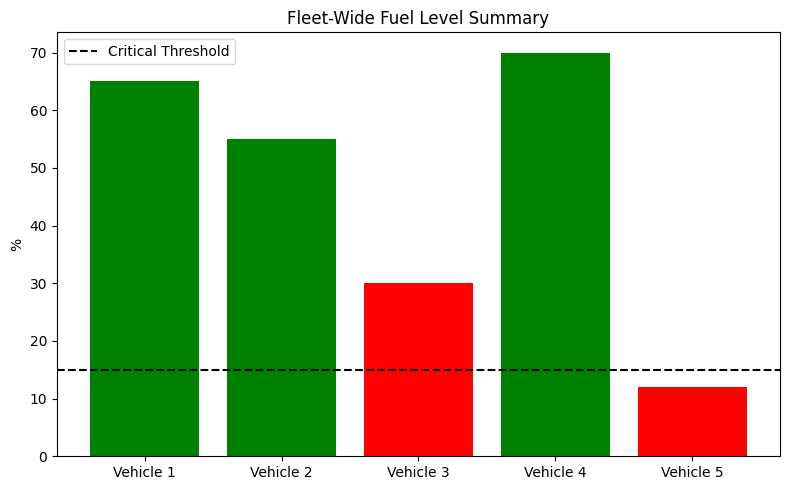

In [1]:

# ===========================================
# Case Study : Vehicle Fleet Health Monitoring System
# Google Colab Simulation (5 Vehicles - Separate Graphs)
# ===========================================

import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

# -------------------------
# Vehicle Names
# -------------------------

vehicles = ["Vehicle 1","Vehicle 2","Vehicle 3","Vehicle 4","Vehicle 5"]

# Fixed realistic readings (guarantees a clean mix of NORMAL/ALERT)
engine_temps = [78.5, 92.0, 108.5, 88.0, 112.0]
rpms         = [1800, 3000, 5200, 2600, 5600]
fuels        = [65, 55, 30, 70, 12]

engine_temp_data=[]
rpm_data=[]
fuel_data=[]
status_data=[]

# -------------------------
# Simulation
# -------------------------

for i, vehicle in enumerate(vehicles):

    engine_temp = engine_temps[i]
    rpm = rpms[i]
    fuel = fuels[i]

    engine_temp_data.append(engine_temp)
    rpm_data.append(rpm)
    fuel_data.append(fuel)

    if engine_temp>105 or rpm>5000 or fuel<15:
        status="ALERT"
    else:
        status="NORMAL"

    status_data.append(status)

    clear_output(wait=True)

    print("="*60)
    print("VEHICLE FLEET HEALTH MONITORING SYSTEM")
    print("="*60)
    print("Vehicle :",vehicle)
    print("Engine Temperature :",engine_temp,"°C")
    print("RPM :",rpm)
    print("Fuel Level :",fuel,"%")
    print("Status :",status)
    print("="*60)

    # ---- Graph 1: Engine Temperature (Separate) ----
    plt.figure(figsize=(6,4))
    plt.bar(["Engine Temp"],[engine_temp],color="orange")
    plt.ylim(60,130)
    plt.axhline(105, color='red', linestyle='--', linewidth=1, label="Critical Limit")
    plt.title(f"{vehicle} - Engine Temperature")
    plt.ylabel("°C")
    plt.legend()
    plt.show()

    # ---- Graph 2: RPM (Separate) ----
    plt.figure(figsize=(6,4))
    plt.bar(["RPM"],[rpm],color="blue")
    plt.ylim(0,7000)
    plt.axhline(5000, color='red', linestyle='--', linewidth=1, label="Critical Limit")
    plt.title(f"{vehicle} - Engine RPM")
    plt.ylabel("RPM")
    plt.legend()
    plt.show()

    # ---- Graph 3: Fuel Level (Separate) ----
    fuel_color = "red" if fuel<15 else "green"
    plt.figure(figsize=(6,4))
    plt.bar(["Fuel"],[fuel],color=fuel_color)
    plt.ylim(0,100)
    plt.axhline(15, color='red', linestyle='--', linewidth=1, label="Critical Limit")
    plt.title(f"{vehicle} - Fuel Level")
    plt.ylabel("%")
    plt.legend()
    plt.show()

    time.sleep(2)

# -------------------------
# Final Report
# -------------------------

report=pd.DataFrame({
    "Vehicle":vehicles,
    "Engine Temperature":engine_temp_data,
    "RPM":rpm_data,
    "Fuel Level":fuel_data,
    "Status":status_data
})

clear_output(wait=True)

print("\nFINAL REPORT\n")
print(report)

alert_count = len(report[report["Status"]=="ALERT"])
normal_count = len(report) - alert_count

print("\nNormal Vehicles :", normal_count)
print("Alert Vehicles  :", alert_count)

report.to_csv("Fleet_Health_Report.csv",index=False)
print("\nCSV File Saved Successfully")

# -------------------------
# Final Summary Graphs (Separate, Fleet-Wide)
# -------------------------

colors_final = ['red' if s=="ALERT" else 'green' for s in status_data]

# Engine Temp Summary
plt.figure(figsize=(8,5))
plt.bar(vehicles, engine_temp_data, color=colors_final)
plt.axhline(105, color='black', linestyle='--', label="Critical Threshold")
plt.title("Fleet-Wide Engine Temperature Summary")
plt.ylabel("°C")
plt.legend()
plt.tight_layout()
plt.show()

# RPM Summary
plt.figure(figsize=(8,5))
plt.bar(vehicles, rpm_data, color=colors_final)
plt.axhline(5000, color='black', linestyle='--', label="Critical Threshold")
plt.title("Fleet-Wide RPM Summary")
plt.ylabel("RPM")
plt.legend()
plt.tight_layout()
plt.show()

# Fuel Summary
plt.figure(figsize=(8,5))
plt.bar(vehicles, fuel_data, color=colors_final)
plt.axhline(15, color='black', linestyle='--', label="Critical Threshold")
plt.title("Fleet-Wide Fuel Level Summary")
plt.ylabel("%")
plt.legend()
plt.tight_layout()
plt.show()